In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
df = pd.read_excel('Book1.xlsx')
df.head(5)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

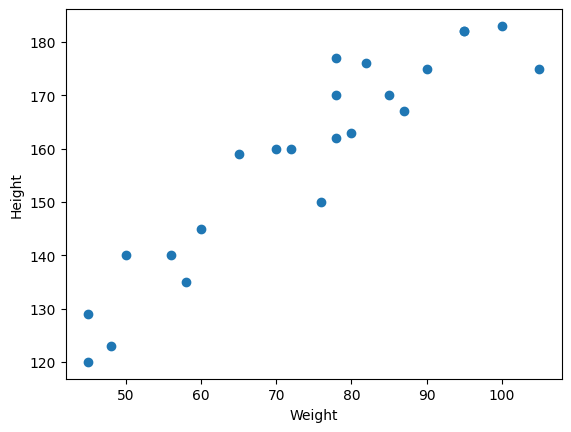

In [5]:
#scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [6]:
##correation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


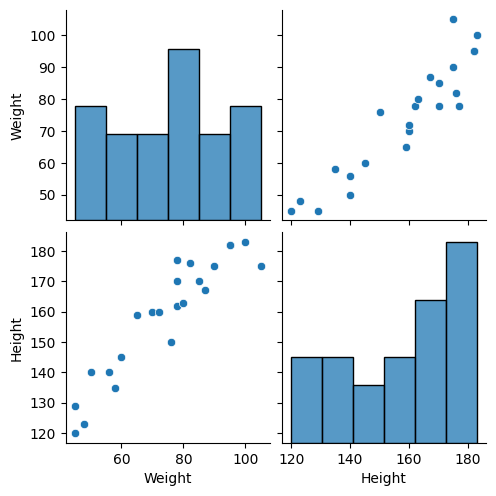

In [7]:
#seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [9]:
## independent and dependent
X=df[['Weight']] #indenpendent should be in dataFrame or 2D array
Y=df['Height'] # this variable can be in series form or 1D array
X.head()


,Weight
0,45
1,58
2,48
3,60
4,70


In [10]:
X_series = df['Weight']
np.array(X_series).shape


(23,)

In [11]:
np.array(Y).shape

(23,)

In [12]:
## train test split
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train, Y_test = train_test_split(X,Y, test_size=0.25, random_state=42)

In [13]:
#standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [14]:
##apply simple linear regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train, Y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.3]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,156.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [15]:
print("Co-efficient or Slope: ", regression.coef_)
print("Intercept: ", regression.intercept_)

Co-efficient or Slope:  [17.2982057]
Intercept:  156.47058823529412


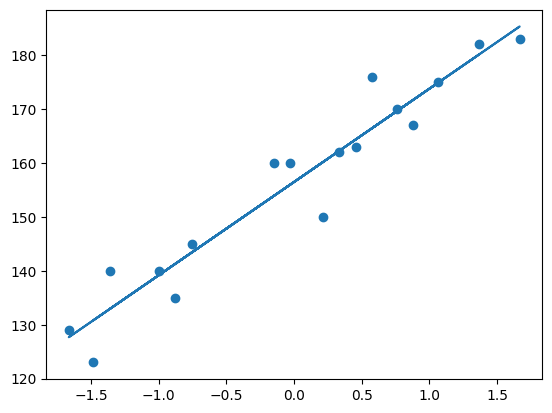

In [16]:
# plot training data plot best fit line
plt.scatter(X_train, Y_train)
plt.plot(X_train, regression.predict(X_train))

### Prediction of test data
1. predictied height output = intercept + coef_(Weights)
2. y_pred_test = 156.47 + 17.29 (X_test)

In [17]:
##prediction for the test data
y_pred = regression.predict(X_test)

In [18]:
## performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


## R Square
Formula
##### R^2 = 1 - SSR/SST
R^2 = Coefficient of determination
SSR = sum of sqr of residuals 
SST = total sum of sqr


In [19]:
from sklearn.metrics import r2_score
score = r2_score(Y_test, y_pred)
print(score)

0.7360826717981276


#### Adjusted R^2 = 1-[(1-R^2)*(n-1)/(n-k-1)]

In [20]:
1-(1-score) * (len(Y_test)-1) / (len(Y_test)-X_test.shape[1]-1)

0.6701033397476595

In [21]:
## ols of linear regression
import statsmodels.api as sm
model = sm.OLS(Y_train,X_train).fit()

In [22]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [23]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 20 Jun 2026   Prob (F-statistic):                       0.664
Time:                        15:32:54   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [26]:
## prediction for new data
regression.predict(scaler.transform([[72]]))

c:\Users\Zobayer\.conda\envs\python_eda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])